<div style="float: right;">
  <a href="../de/bias_baseline.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/bias_baseline.html">English</a>
</div>

# 1. Omitted Variable Bias


### What is Omitted Variable Bias?

Imagine trying to evaluate which factors have an impact on someone's hourly wage,
such as age, education, and work experience. Your formula works reasonably well,
but you forgot to include one important factor: whether the person identifies as
male or female. Because wages differ systematically between men and women in the
real world, the model tasked with evaluating the impact of each factor will be
"confused." It tries to fit *everyone* with a single average pattern, which ends
up being wrong in different directions for each group.

This is called **omitted variable bias**: when an important factor is left out of
a model, the model's predictions become systematically skewed, often in ways that
hurt specific groups.

In this tutorial, we use a synthetic (artificially generated) wage dataset to see
exactly what happens when we **leave sex out** of a wage prediction model.

In [1]:
# ── Import the tools we need ───────────────────────────────────────────────
import pandas as pd                                    # loading and handling data
import numpy as np                                     # numerical operations
import matplotlib.pyplot as plt                        # creating charts
from sklearn.model_selection import train_test_split   # splitting data into train/test sets
from sklearn.linear_model import LinearRegression      # our wage prediction model
from sklearn.metrics import mean_squared_error         # measuring prediction errors
import ipywidgets as widgets                           # interactive checkboxes & buttons
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# ── Load the dataset ───────────────────────────────────────────────────────
# wages.csv was generated by generate_wages.py
df = pd.read_csv("wages.csv")

print(f"Loaded {len(df)} workers with {len(df.columns)} variables each.")
df.head()

Loaded 4000 workers with 7 variables each.


,age,education,experience,hours_per_week,tenure,sex,wage
0,51,12,33.983332,31.537400,0.107181,0,32.409885
1,41,13,25.000000,41.498692,4.303800,1,34.320540
2,32,15,14.000000,32.797004,0.812251,1,28.138393
3,43,14,23.541497,38.857087,0.062242,1,34.895287
4,33,15,9.086144,23.024405,0.553826,0,22.008015


In [2]:
# ── Prepare the data for modelling ────────────────────────────────────────

# The columns we will use as inputs to predict wages
feature_cols = ['age', 'education', 'experience', 'hours_per_week', 'tenure', 'sex']

# Human-readable labels used in the interactive widget below
feature_labels = {
    'age':            'Age',
    'education':      'Education (years)',
    'experience':     'Experience (years)',
    'hours_per_week': 'Hours/Week',
    'tenure':         'Tenure (years)',
    'sex':            'Sex',
}

# Split the dataset: 70% for training the model, 30% for testing it
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)
df_test = df_test.copy()  # avoids a pandas warning when we add columns later

# Separate the input columns from the outcome we want to predict
X_train = df_train[feature_cols]
X_test  = df_test[feature_cols]
y_train = df_train['wage']
y_test  = df_test['wage']

# RMSE (Root Mean Squared Error) = average prediction error in $/hr — lower is better
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Training set: {len(df_train)} workers  |  Test set: {len(df_test)} workers")

Training set: 2800 workers  |  Test set: 1200 workers


## Why does sex matter for wage prediction?

Before building any models, let's look at how wages are spread across the two groups.
The chart below is a **histogram**: each bar shows how many people earn wages in a given
range. When the two groups have very different distributions, a model that ignores group
membership will struggle to predict wages accurately for either group.

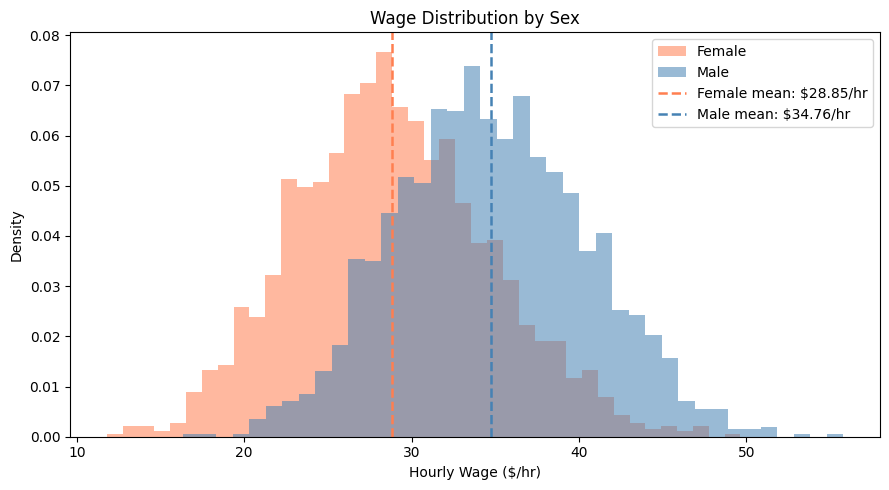

Mean wage — Female: $28.85/hr  |  Male: $34.76/hr
Gap: $5.91/hr


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

female_wages = df.loc[df['sex'] == 0, 'wage']
male_wages   = df.loc[df['sex'] == 1, 'wage']

ax.hist(female_wages, bins=40, alpha=0.55, color='coral',     label='Female', density=True)
ax.hist(male_wages,   bins=40, alpha=0.55, color='steelblue', label='Male',   density=True)

ax.axvline(female_wages.mean(), color='coral',    linestyle='--', linewidth=1.8,
           label=f'Female mean: ${female_wages.mean():.2f}/hr')
ax.axvline(male_wages.mean(),   color='steelblue', linestyle='--', linewidth=1.8,
           label=f'Male mean: ${male_wages.mean():.2f}/hr')

ax.set_xlabel('Hourly Wage ($/hr)')
ax.set_ylabel('Density')
ax.set_title('Wage Distribution by Sex')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean wage — Female: ${female_wages.mean():.2f}/hr  |  Male: ${male_wages.mean():.2f}/hr")
print(f"Gap: ${male_wages.mean() - female_wages.mean():.2f}/hr")

The two wage distributions are clearly shifted relative to each other. A model that
cannot tell men from women will apply a single "average" wage formula to everyone
which will systematically over-predict wages for women and under-predict for men.

## Training Two Models

We now train two **linear regression** models on the same data, attempting to find
a linear relationship between the input variables (like age or education) and wages.

- **Model WITH sex**: uses age, education, experience, hours per week, tenure, *and* sex
- **Model WITHOUT sex**: uses everything *except* sex using `.drop(columns=['sex'])`

In [4]:
# ── Model WITH sex ─────────────────────────────────────────────────────────
lr_with = LinearRegression()
lr_with.fit(X_train, y_train)

# ── Model WITHOUT sex ──────────────────────────────────────────────────────
# Dropping a column from a DataFrame is straightforward:
lr_without = LinearRegression()
lr_without.fit(X_train.drop(columns=['sex']), y_train)

# ── Store predictions and residuals as new columns in the test table ───────
# This lets us filter by sex easily in the next steps — no index tricks needed.
df_test['pred_with']     = lr_with.predict(X_test)
df_test['pred_without']  = lr_without.predict(X_test.drop(columns=['sex']))
df_test['resid_with']    = df_test['pred_with']    - df_test['wage']
df_test['resid_without'] = df_test['pred_without'] - df_test['wage']

print(f"Model WITH sex:    RMSE = {rmse(y_test, df_test['pred_with']):.3f} $/hr")
print(f"Model WITHOUT sex: RMSE = {rmse(y_test, df_test['pred_without']):.3f} $/hr")

Model WITH sex:    RMSE = 3.002 $/hr
Model WITHOUT sex: RMSE = 3.651 $/hr


The overall error is already higher when sex is omitted. But the overall number
hides *who* the model is getting wrong. Let's break the error down by sex group.

In [5]:
# Filter the test set by sex
female = df_test[df_test['sex'] == 0]
male   = df_test[df_test['sex'] == 1]

female_rmse_with    = rmse(female['wage'], female['pred_with'])
male_rmse_with      = rmse(male['wage'],   male['pred_with'])
female_rmse_without = rmse(female['wage'], female['pred_without'])
male_rmse_without   = rmse(male['wage'],   male['pred_without'])

print("Prediction error by group (RMSE in $/hr):")
print(f"  Model WITH sex     Female: {female_rmse_with:.2f}  Male: {male_rmse_with:.2f}")
print(f"  Model WITHOUT sex  Female: {female_rmse_without:.2f}  Male: {male_rmse_without:.2f}")

Prediction error by group (RMSE in $/hr):
  Model WITH sex     Female: 3.07  Male: 2.93
  Model WITHOUT sex  Female: 3.71  Male: 3.59


The bar chart below makes the group-level differences easy to see at a glance.
Each pair of bars shows the prediction error for women (left) and men (right),
comparing the model that includes sex (blue) with the one that does not (coral).

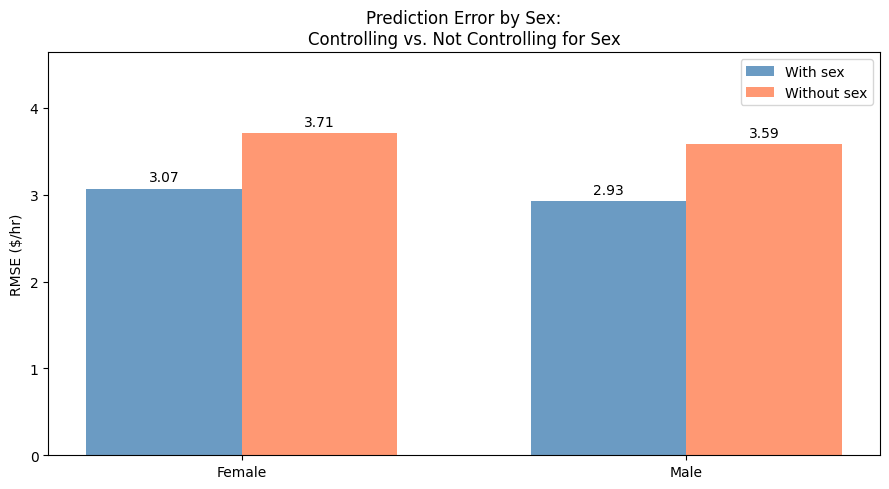

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [female_rmse_with, male_rmse_with], width,
               label='With sex', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [female_rmse_without, male_rmse_without], width,
               label='Without sex', color='coral', alpha=0.8)

ax.set_ylabel('RMSE ($/hr)')
ax.set_title('Prediction Error by Sex:\nControlling vs. Not Controlling for Sex')
ax.set_xticks(x)
ax.set_xticklabels(['Female', 'Male'])
ax.legend()
ax.set_ylim(0, max(female_rmse_without, male_rmse_without) * 1.25)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Residual Analysis

While the RMSE gives us a general idea of how large the errors are, we still
don't know if the model is over-predicting or under-predicting wages for each
group. To investigate that, we look at **residuals**, the difference between
what the model predicted and what the actual wage was:

> **Residual = Predicted wage − Actual wage**

- A **positive** residual means the model predicted *too high* (over-prediction).
- A **negative** residual means the model predicted *too low* (under-prediction).
- Residuals clustered near **zero** mean the model is unbiased on average.

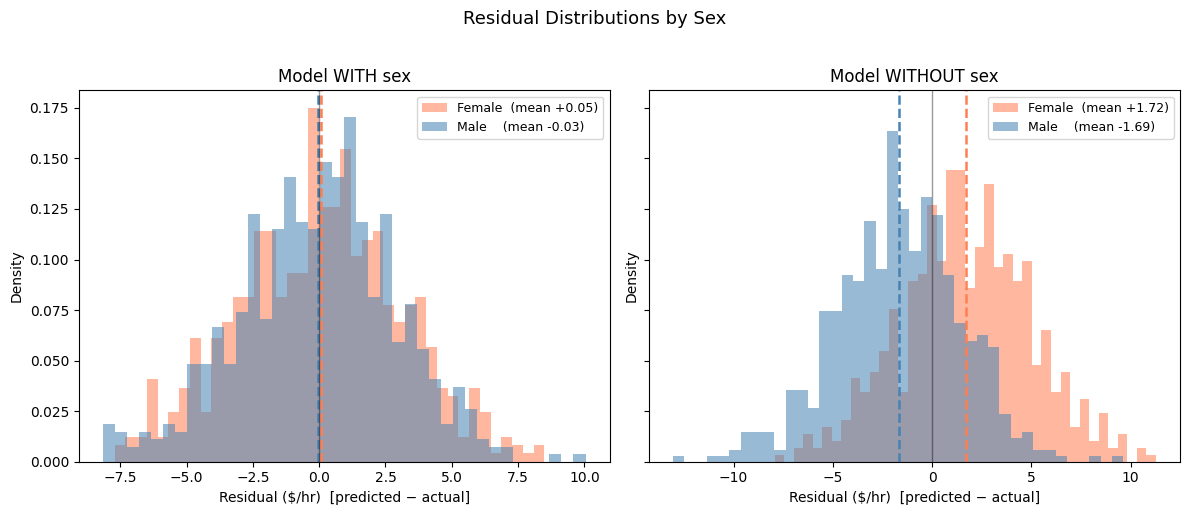

Mean residuals:
  WITH sex     Female: +0.054  Male: -0.033
  WITHOUT sex  Female: +1.721  Male: -1.687


In [7]:
# Plot residual histograms side by side
# 'female' and 'male' already contain the residual columns from the training step
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, col, title in [
    (axes[0], 'resid_with',    'Model WITH sex'),
    (axes[1], 'resid_without', 'Model WITHOUT sex'),
]:
    ax.hist(female[col], bins=40, alpha=0.55, color='coral',
            label=f'Female  (mean {female[col].mean():+.2f})', density=True)
    ax.hist(male[col],   bins=40, alpha=0.55, color='steelblue',
            label=f'Male    (mean {male[col].mean():+.2f})', density=True)
    ax.axvline(female[col].mean(), color='coral',     linestyle='--', linewidth=1.8)
    ax.axvline(male[col].mean(),   color='steelblue', linestyle='--', linewidth=1.8)
    ax.axvline(0, color='black', linewidth=1, alpha=0.4)   # perfect prediction line
    ax.set_xlabel('Residual ($/hr)  [predicted − actual]')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Residual Distributions by Sex', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Mean residuals:")
print(f"  WITH sex     Female: {female['resid_with'].mean():+.3f}  Male: {male['resid_with'].mean():+.3f}")
print(f"  WITHOUT sex  Female: {female['resid_without'].mean():+.3f}  Male: {male['resid_without'].mean():+.3f}")

When sex is included, the average residual for both groups is close to zero,
the model is not systematically wrong for either group. When sex is omitted,
the model cannot account for the wage gap, so it over-predicts for women
(positive residuals) and under-predicts for men (negative residuals) by roughly
$1.7/hr in each direction.

## Interactive Feature Explorer

So far we compared just two configurations: all variables included, versus all
variables minus sex. But what happens when you remove other variables  or several
at once?

Use the checkboxes below to choose which variables to include, then click
**Train & Evaluate** to see how the prediction errors shift for women and men.
Try removing education, or tenure, and see if the bias changes direction.

In [8]:
# Create one checkbox per variable (all ticked by default)
checkboxes = {col: widgets.Checkbox(value=True, description=feature_labels[col],
              style={'description_width': 'initial'}, layout=widgets.Layout(width='220px'))
              for col in feature_cols}

button      = widgets.Button(description='Train & Evaluate', button_style='primary',
                             icon='play', layout=widgets.Layout(width='200px', height='36px'))
output_area = widgets.Output()

def train_and_evaluate(_):
    selected = [col for col, cb in checkboxes.items() if cb.value]
    with output_area:
        clear_output(wait=True)
        if not selected:
            print("Please select at least one feature.")
            return

        # Train a fresh model using only the selected columns
        lr = LinearRegression()
        lr.fit(df_train[selected], y_train)

        # Build a small results table for easy group-level analysis
        results = df_test[['sex', 'wage']].copy()
        results['pred']  = lr.predict(df_test[selected])
        results['resid'] = results['pred'] - results['wage']

        # Filter by sex: same readable pattern as in the main analysis above
        f = results[results['sex'] == 0]
        m = results[results['sex'] == 1]

        f_rmse = rmse(f['wage'], f['pred'])
        m_rmse = rmse(m['wage'], m['pred'])

        print(f"Features used ({len(selected)}): {', '.join(feature_labels[c] for c in selected)}")
        print("=" * 60)
        print(f"  Overall RMSE:  {rmse(y_test, results['pred']):.3f} $/hr")
        print(f"  Female — RMSE: {f_rmse:.3f}  mean residual: {f['resid'].mean():+.3f} $/hr")
        print(f"  Male   — RMSE: {m_rmse:.3f}  mean residual: {m['resid'].mean():+.3f} $/hr")

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(f['resid'], bins=40, alpha=0.55, color='coral',
                label=f'Female  (mean {f["resid"].mean():+.2f}, RMSE {f_rmse:.2f})', density=True)
        ax.hist(m['resid'], bins=40, alpha=0.55, color='steelblue',
                label=f'Male    (mean {m["resid"].mean():+.2f}, RMSE {m_rmse:.2f})', density=True)
        ax.axvline(f['resid'].mean(), color='coral',     linestyle='--', linewidth=1.8)
        ax.axvline(m['resid'].mean(), color='steelblue', linestyle='--', linewidth=1.8)
        ax.axvline(0, color='black', linewidth=1, alpha=0.4)
        ax.set_xlabel('Residual ($/hr)  [predicted − actual]')
        ax.set_ylabel('Density')
        ax.set_title('Residual Distribution by Sex')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

button.on_click(train_and_evaluate)

cb_list   = list(checkboxes.values())
left_col  = widgets.VBox(cb_list[:3])
right_col = widgets.VBox(cb_list[3:])

display(widgets.VBox([widgets.HBox([left_col, right_col]), button, output_area]))

## Key Observations

By comparing the two models, we can draw several important conclusions about
how omitting a variable introduces bias:

- **Without sex, the model treats everyone the same**: It applies a single
  "one size fits all" wage formula, which over-predicts wages for women and
  under-predicts wages for men — by roughly $5/hr in each direction.
- **Residuals show which direction the model is wrong**: RMSE only tells you
  *how wrong* the model is. Residual histograms reveal *who* the model
  systematically favours or disfavours — a clear sign of omitted variable bias.
- **Including sex fixes the problem**: When the model knows about sex, it can
  learn group-specific patterns and its errors shrink roughly by half for each group.
- **Other variables matter too**: Use the interactive tool above to explore what
  happens when you remove education, tenure, or other variables — some omissions
  affect women more, others affect men more.